# Probability of Default (PD) Model & Expected Loss Calculator
# Credit Risk
    Pipeline
    --------
      1. Load & explore the loan data (EDA)
      2. Feature engineering
      3. Train 3 models: Logistic Regression, Random Forest, XGBoost
      4. Evaluate & compare (ROC-AUC, Precision-Recall, KS statistic)
      5. Select best model
      6. expected_loss() — the production-ready function:
           inputs  : loan features
           outputs : PD, Expected Loss  (assuming 10% recovery rate)

In [8]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import joblib

# Import and understand data

In [9]:
df = pd.read_csv("Loan_Data.csv")
print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Default rate : {df['default'].mean():.2%}  ({df['default'].sum():,} defaults)")
print(f"Missing vals : {df.isnull().sum().sum()}")
print("\nFeature summary:")
print(df.drop(columns=["customer_id","default"]).describe().round(2).to_string())

Shape        : 10,000 rows × 8 columns
Default rate : 18.51%  (1,851 defaults)
Missing vals : 0

Feature summary:
       credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding     income  years_employed  fico_score
count                  10000.00              10000.00                10000.00   10000.00        10000.00    10000.00
mean                       1.46               4159.68                 8718.92   70039.90            4.55      637.56
std                        1.74               1421.40                 6627.16   20072.21            1.57       60.66
min                        0.00                 46.78                   31.65    1000.00            0.00      408.00
25%                        0.00               3154.24                 4199.84   56539.87            3.00      597.00
50%                        1.00               4052.38                 6732.41   70085.83            5.00      638.00
75%                        2.00               5052.90              

# EDA plots

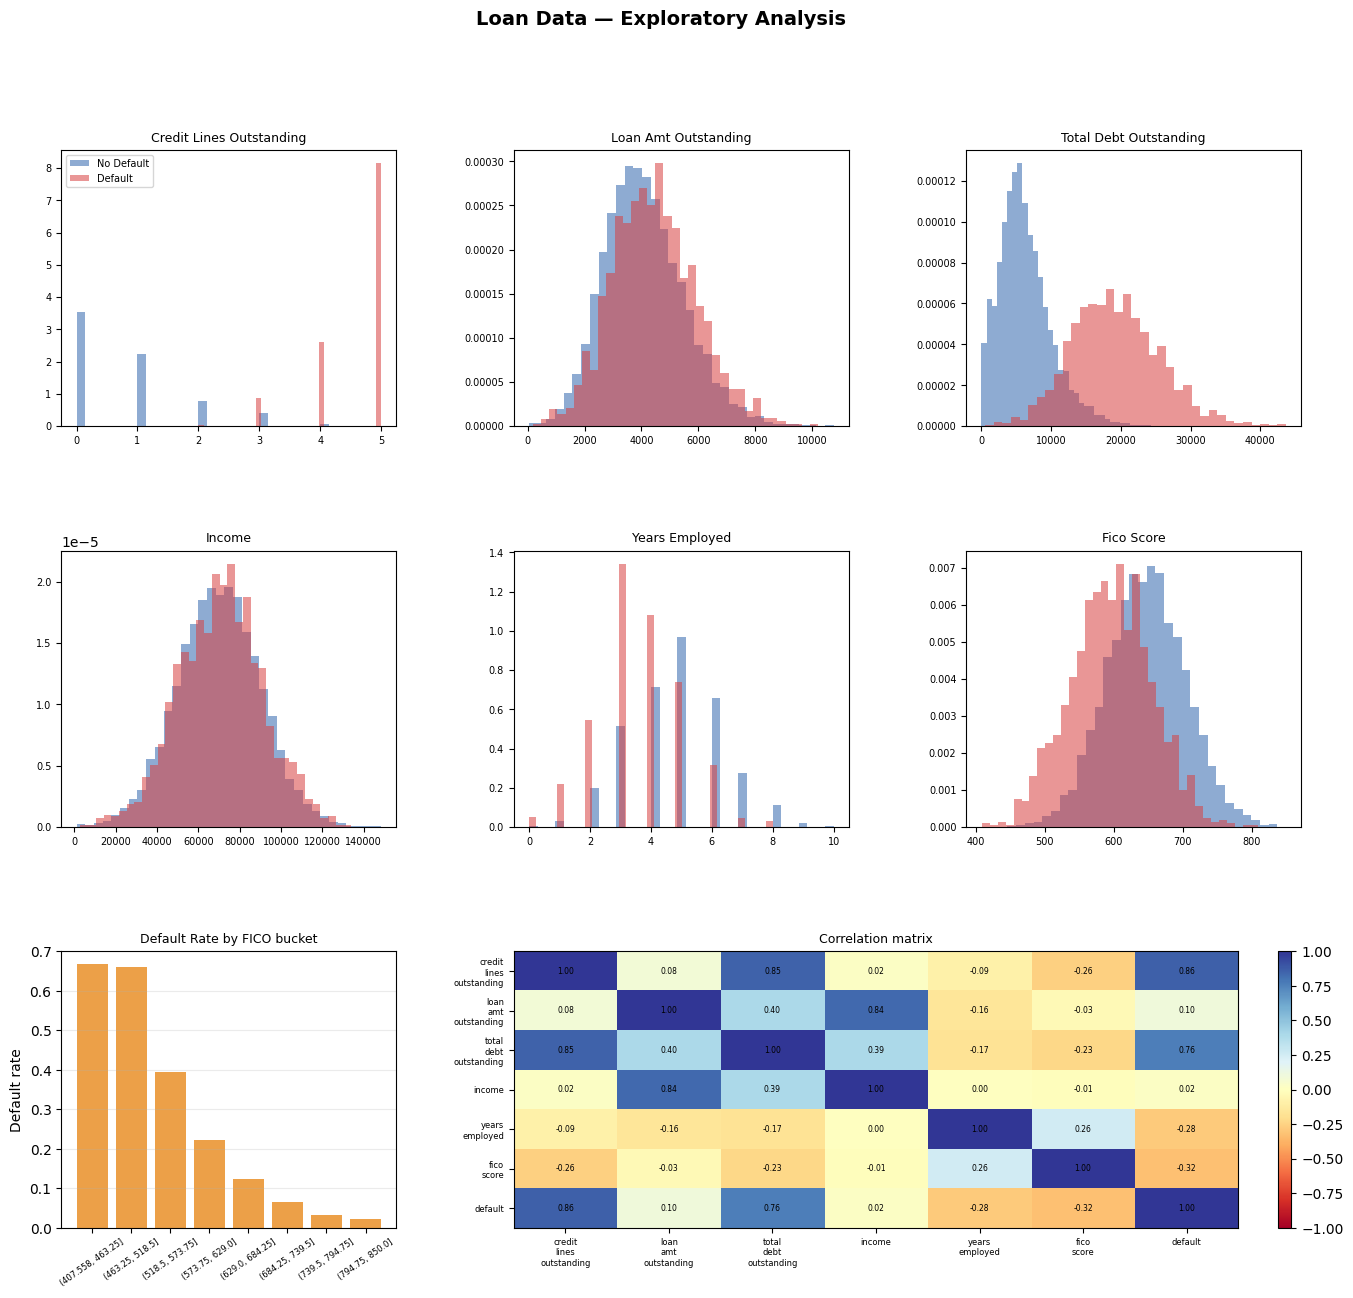

In [11]:
features = ["credit_lines_outstanding","loan_amt_outstanding",
            "total_debt_outstanding","income","years_employed","fico_score"]

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Loan Data — Exploratory Analysis", fontsize=14, fontweight="bold")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Distribution of each feature by default status
colors = {0: "#3266ad", 1: "#d84040"}
for i, feat in enumerate(features):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    for label, grp in df.groupby("default"):
        ax.hist(grp[feat], bins=35, alpha=0.55,
                color=colors[label],
                label=f"{'Default' if label else 'No Default'}",
                density=True)
    ax.set_title(feat.replace("_", " ").title(), fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

# Default rate by FICO bucket
ax_fico = fig.add_subplot(gs[2, 0])
df["fico_bucket"] = pd.cut(df["fico_score"], bins=8)
dr_fico = df.groupby("fico_bucket", observed=True)["default"].mean()
ax_fico.bar(range(len(dr_fico)), dr_fico.values, color="#e8891a", alpha=0.8)
ax_fico.set_xticks(range(len(dr_fico)))
ax_fico.set_xticklabels([str(x) for x in dr_fico.index], rotation=35, fontsize=6)
ax_fico.set_title("Default Rate by FICO bucket", fontsize=9)
ax_fico.set_ylabel("Default rate")
ax_fico.grid(True, alpha=0.25, axis="y")

# Correlation heatmap
ax_corr = fig.add_subplot(gs[2, 1:])
corr = df[features + ["default"]].corr()
im = ax_corr.imshow(corr, cmap="RdYlBu", vmin=-1, vmax=1, aspect="auto")
ticks = features + ["default"]
ax_corr.set_xticks(range(len(ticks)))
ax_corr.set_yticks(range(len(ticks)))
ax_corr.set_xticklabels([t.replace("_","\n") for t in ticks], fontsize=6)
ax_corr.set_yticklabels([t.replace("_","\n") for t in ticks], fontsize=6)
for i in range(len(ticks)):
    for j in range(len(ticks)):
        ax_corr.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=5.5)
ax_corr.set_title("Correlation matrix", fontsize=9)
plt.colorbar(im, ax=ax_corr, fraction=0.03)
df.drop(columns=["fico_bucket"], inplace=True)


# Feature Engineering

In [12]:
df_m = df.copy()

# Debt-to-income ratio
df_m["debt_to_income"]      = df_m["total_debt_outstanding"] / (df_m["income"] + 1)

# Loan-to-income ratio
df_m["loan_to_income"]      = df_m["loan_amt_outstanding"]   / (df_m["income"] + 1)

# Total obligations relative to income
df_m["total_obligations"]   = (df_m["total_debt_outstanding"] + df_m["loan_amt_outstanding"]) / (df_m["income"] + 1)

# FICO inverse (higher score = lower risk signal)
df_m["fico_inv"]            = 850 - df_m["fico_score"]

# Log-transform skewed continuous features
for col in ["income", "total_debt_outstanding", "loan_amt_outstanding"]:
    df_m[f"log_{col}"] = np.log1p(df_m[col])

feature_cols = [
    "credit_lines_outstanding",
    "loan_amt_outstanding", "log_loan_amt_outstanding",
    "total_debt_outstanding", "log_total_debt_outstanding",
    "income", "log_income",
    "years_employed",
    "fico_score", "fico_inv",
    "debt_to_income", "loan_to_income", "total_obligations"
]

X = df_m[feature_cols]
y = df_m["default"]
print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} columns")
print("Features:", feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")


Feature matrix: 10,000 rows × 13 columns
Features: ['credit_lines_outstanding', 'loan_amt_outstanding', 'log_loan_amt_outstanding', 'total_debt_outstanding', 'log_total_debt_outstanding', 'income', 'log_income', 'years_employed', 'fico_score', 'fico_inv', 'debt_to_income', 'loan_to_income', 'total_obligations']

Train: 8,000  |  Test: 2,000
Train default rate: 18.51%  |  Test: 18.50%


# Train Three Models

## Logistic Regression

In [13]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_cv = cross_val_score(lr_pipe, X_train, y_train, cv=5,
                        scoring="roc_auc", n_jobs=-1).mean()
print(f"  5-fold CV ROC-AUC : {lr_cv:.4f}")

  5-fold CV ROC-AUC : 1.0000


## Random Forest

In [14]:
rf_pipe = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
rf_cv = cross_val_score(rf_pipe, X_train, y_train, cv=5,
                        scoring="roc_auc", n_jobs=-1).mean()
print(f"  5-fold CV ROC-AUC : {rf_cv:.4f}")

  5-fold CV ROC-AUC : 0.9991


##  XGBoost

In [16]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="logloss", use_label_encoder=False,
        random_state=42, n_jobs=-1, verbosity=0
    ))
])
xgb_pipe.fit(X_train, y_train)
xgb_cv = cross_val_score(xgb_pipe, X_train, y_train, cv=5,
                         scoring="roc_auc", n_jobs=-1).mean()
print(f"  5-fold CV ROC-AUC : {xgb_cv:.4f}")

  5-fold CV ROC-AUC : 0.9999


# Evaluate & Compare

In [17]:
models = {
    "Logistic Regression": lr_pipe,
    "Random Forest":       rf_pipe,
    "XGBoost":             xgb_pipe,
}
cv_scores = {
    "Logistic Regression": lr_cv,
    "Random Forest":       rf_cv,
    "XGBoost":             xgb_cv,
}

results = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    ap    = average_precision_score(y_test, proba)

    # KS statistic
    fpr, tpr, _ = roc_curve(y_test, proba)
    ks = (tpr - fpr).max()

    results[name] = {"AUC": auc, "AP": ap, "KS": ks,
                     "CV_AUC": cv_scores[name], "proba": proba}
    print(f"\n{name}")
    print(f"  Test ROC-AUC : {auc:.4f}")
    print(f"  Avg Precision: {ap:.4f}")
    print(f"  KS statistic : {ks:.4f}")
    print(f"  CV ROC-AUC   : {cv_scores[name]:.4f}")


Logistic Regression
  Test ROC-AUC : 1.0000
  Avg Precision: 0.9999
  KS statistic : 0.9969
  CV ROC-AUC   : 1.0000

Random Forest
  Test ROC-AUC : 0.9989
  Avg Precision: 0.9955
  KS statistic : 0.9708
  CV ROC-AUC   : 0.9991

XGBoost
  Test ROC-AUC : 1.0000
  Avg Precision: 0.9998
  KS statistic : 0.9942
  CV ROC-AUC   : 0.9999


# Comparison plots

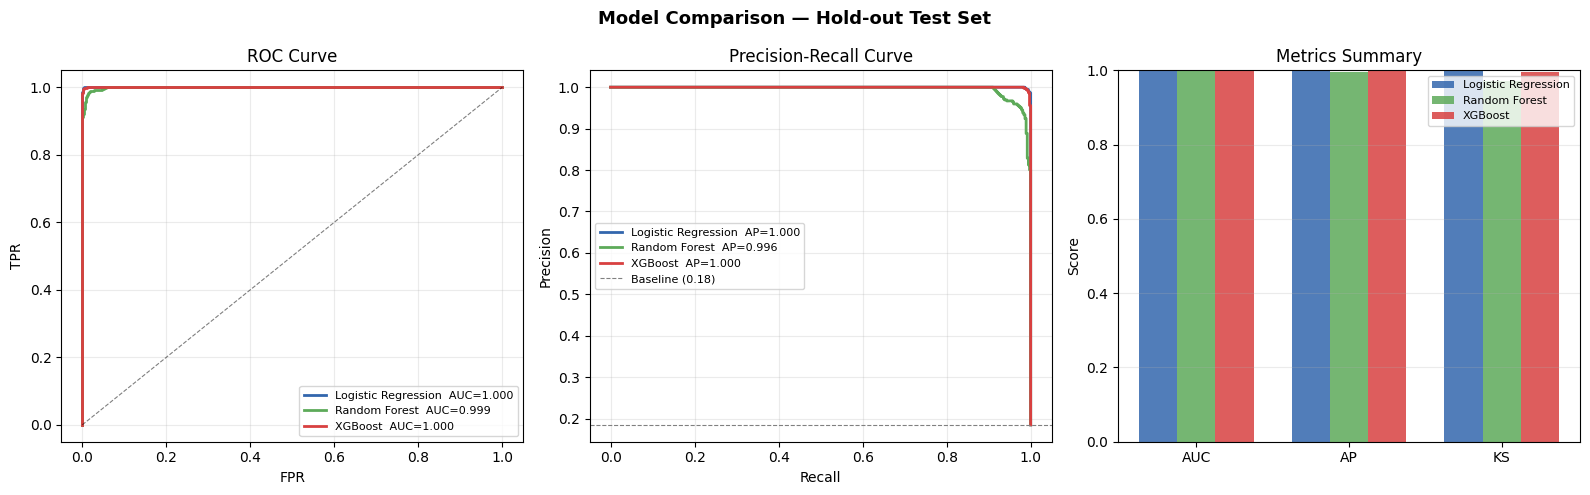

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Hold-out Test Set", fontsize=13, fontweight="bold")

pal = {"Logistic Regression": "#3266ad",
       "Random Forest":       "#5daa59",
       "XGBoost":             "#d84040"}

# ROC curves
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, label=f"{name}  AUC={res['AUC']:.3f}",
            color=pal[name], linewidth=2)
ax.plot([0,1],[0,1],"k--", linewidth=0.8, alpha=0.5)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# Precision-Recall curves
ax = axes[1]
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    ax.plot(rec, prec, label=f"{name}  AP={res['AP']:.3f}",
            color=pal[name], linewidth=2)
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=0.8,
           label=f"Baseline ({baseline:.2f})")
ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# Bar chart of metrics
ax = axes[2]
metric_names = ["AUC", "AP", "KS"]
x = np.arange(len(metric_names))
w = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res["AUC"], res["AP"], res["KS"]]
    ax.bar(x + i*w, vals, width=w, label=name, color=pal[name], alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(metric_names)
ax.set_title("Metrics Summary")
ax.set_ylabel("Score"); ax.legend(fontsize=8)
ax.set_ylim(0, 1); ax.grid(True, alpha=0.25, axis="y")

plt.tight_layout()

# Feature importance (XGBoost)

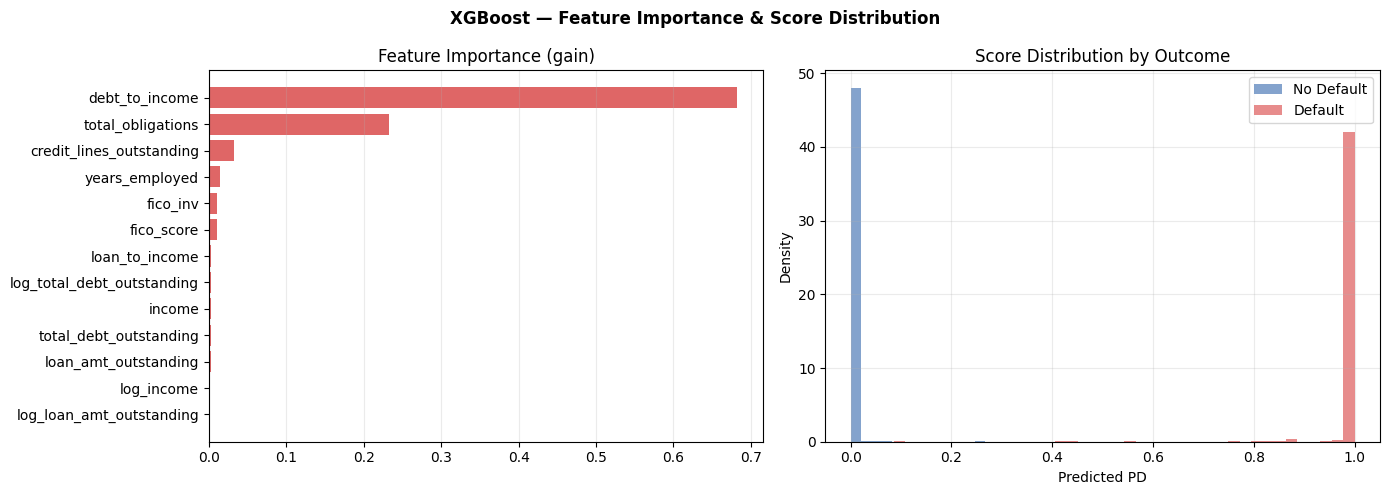

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("XGBoost — Feature Importance & Score Distribution", fontsize=12, fontweight="bold")

ax = axes[0]
imp = xgb_pipe.named_steps["clf"].feature_importances_
order = np.argsort(imp)[::-1]
ax.barh([feature_cols[i] for i in order], imp[order], color="#d84040", alpha=0.8)
ax.set_title("Feature Importance (gain)")
ax.invert_yaxis(); ax.grid(True, alpha=0.25, axis="x")

ax = axes[1]
xgb_proba = results["XGBoost"]["proba"]
ax.hist(xgb_proba[y_test==0], bins=40, alpha=0.6, density=True,
        color="#3266ad", label="No Default")
ax.hist(xgb_proba[y_test==1], bins=40, alpha=0.6, density=True,
        color="#d84040", label="Default")
ax.set_title("Score Distribution by Outcome")
ax.set_xlabel("Predicted PD"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.25)

plt.tight_layout()